# Medical QA System: Fine-Tuning ClinicalBERT with Retrieval-Augmented Generation

## 1.1. Project Overview: Pressure Ulcer QA Model

The purpose of this notebook is to train a BERT Large Language Model to answer healthcare practitioners' questions about pressure ulcers, effectively supporting their ongoing training.

This notebook encompasses the complete deep learning pipeline, including downloading relevant peer-reviewed articles, preprocessing a custom SQuAD-formatted dataset, and applying necessary tokenization. Next, a Clinical BERT model is fine-tuned, deployed and evaluated on unseen test data, utilizing metrics like BERTScore to assess precision, recall, and F1 scores.

## 1.2. Imports

In [3]:
# --- Standard Library & Utilities ---
import glob
import json
import os
import random
import re
import time
import uuid
from pathlib import Path
from tqdm.notebook import tqdm  # Optimized for Jupyter Notebook outputs

# --- Machine Learning (Core) ---
import torch

# --- Web Scraping & Data Handling ---
import requests
from bs4 import BeautifulSoup

# --- NLP Frameworks (Transformers & LangChain) ---
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoModel, AutoTokenizer
from transformers.data.processors.squad import SquadV2Processor
from sentence_transformers import SentenceTransformer

# --- Vector Database (Qdrant) ---
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams

# --- Evaluation Metrics ---
from bert_score import score
from transformers.data.metrics.squad_metrics import squad_evaluate

print("PyTorch-GPU is available:", torch.cuda.is_available())

PyTorch-GPU is available: True


## 1.3. Download Articles

The download_pmc_articles function connects to the NCBI E-utilities API to query PubMed Central for open-access research papers specifically containing "pressure ulcer" in the title. To respect NCBI rate limits, the script retrieves the XML data in batches. BeautifulSoup is then used to parse the responses, carefully stripping away metadata and HTML tags to isolate the clean paragraph text from the article bodies. Finally, this raw clinical corpus is serialized and saved as a JSON file, preparing the data for the next phase.

In [ ]:
def download_pmc_articles(query, max_articles=1000, batch_size=100):
    """
    Searches PubMed Central (PMC) for open-access articles and downloads their full text.
    """
    # Base URLs for NCBI E-utilities
    search_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    fetch_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
    
    print(f"Searching PMC for: '{query}'...")
    
    # 1. Search for article IDs (Restricting to Open Access for full text)
    search_params = {
        "db": "pmc",
        "term": f"{query} AND open access[filter]",
        "retmax": max_articles,
        "retmode": "json"
    }
    
    search_response = requests.get(search_url, params=search_params)
    search_response.raise_for_status()
    id_list = search_response.json()["esearchresult"]["idlist"]
    
    print(f"Found {len(id_list)} article IDs. Beginning bulk download...\n")
    
    articles_data = []
    
    # 2. Fetch full texts in batches to prevent API timeouts and respect NCBI rate limits
    for i in range(0, len(id_list), batch_size):
        batch_ids = id_list[i:i + batch_size]
        print(f"Fetching batch {i//batch_size + 1} (Processing IDs {i} to {i + len(batch_ids) - 1})...")
        
        fetch_params = {
            "db": "pmc",
            "id": ",".join(batch_ids),
            "retmode": "xml"
        }
        
        time.sleep(1) 
        
        fetch_response = requests.get(fetch_url, params=fetch_params)
        
        if fetch_response.status_code == 200:
            # 3. Parse the XML to extract the full body text
            soup = BeautifulSoup(fetch_response.content, "xml")
            articles = soup.find_all("article")
            
            for article in articles:
                # Extract PMC ID
                pmcid_tag = article.find("article-id", {"pub-id-type": "pmcid"})
                pmcid = pmcid_tag.text if pmcid_tag else "Unknown"
                
                # Extract Title
                title_tag = article.find("article-title")
                title = title_tag.text if title_tag else "No Title"
                
                # Extract all paragraph text strictly from the body (ignoring references/metadata)
                body = article.find("body")
                if body:
                    # Clean the text by stripping HTML tags and excess whitespace
                    paragraphs = [p.text.strip() for p in body.find_all("p") if p.text.strip()]
                    full_text = " ".join(paragraphs)
                    
                    # Only append if the article yielded usable text
                    if len(full_text) > 100: 
                        articles_data.append({
                            "pmcid": pmcid,
                            "title": title,
                            "text": full_text
                        })
        else:
            print(f"Error: Failed to fetch batch {i//batch_size + 1}. Status Code: {fetch_response.status_code}")
            
    print(f"\nPipeline Complete: Successfully downloaded and parsed {len(articles_data)} full-text articles.")
    return articles_data


# Define the clinical query
query = '("pressure ulcer"[Title])'

# Run the pipeline
raw_corpus = download_pmc_articles(query, max_articles=1000)

# Serialize the dataset to JSON to prepare for Phase 2 (Chunking and QA Generation)
raw_dataset_path = "dataset/pressure_ulcer_corpus_raw.json"
output_file = Path(raw_dataset_path)
output_file.parent.mkdir(parents=True, exist_ok=True)

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(raw_corpus, f, indent=4, ensure_ascii=False)
    
print(f"Raw clinical corpus saved to '{output_file}'. Ready for preprocessing.")

Searching PMC for: '("pressure ulcer"[Title])'...
Found 382 article IDs. Beginning bulk download...

Fetching batch 1 (Processing IDs 0 to 99)...
Fetching batch 2 (Processing IDs 100 to 199)...
Fetching batch 3 (Processing IDs 200 to 299)...
Fetching batch 4 (Processing IDs 300 to 381)...

Pipeline Complete: Successfully downloaded and parsed 180 full-text articles.
Raw clinical corpus saved to 'dataset\pressure_ulcer_corpus_raw.json'. Ready for preprocessing.


## 1.2. Load Articles for Processing

In [5]:
# Load the downloaded articles
with open(raw_dataset_path, 'r', encoding='utf-8') as f:
    articles = json.load(f)

print(f"Successfully loaded {len(articles)} articles.")
# Display the first article's keys to verify structure
print("Keys in data:", articles[0].keys())

Successfully loaded 180 articles.
Keys in data: dict_keys(['pmcid', 'title', 'text'])


## 1.3. Clean Articles

Scientific articles from PubMed Central frequently contain embedded citation brackets (e.g., [1, 2]) and irregular spacing that introduce noise and hinder language model performance. This function targets and removes numeric citation patterns while normalizing all whitespace and newline characters. Applying this standardizing filter across the dataset ensures a high-quality, continuous text stream.

In [6]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Remove citation brackets e.g., [1], [1, 2, 3]
    text = re.sub(r'\[\d+(?:,\s*\d+)*\]', '', text)
    
    # Remove excessive whitespaces and newlines
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

# Apply cleaning to the dataset
for article in articles:
    article['cleaned_text'] = clean_text(article['text'])

print("Cleaning complete. Example of cleaned text snippet:")
print(articles[0]['cleaned_text'][:300] + "...")

Cleaning complete. Example of cleaned text snippet:
Leriche syndrome is a very peculiar and typical syndrome related to thrombotic obliteration of the end of the abdominal aorta. 1 Although no previous studies have reported on buttock pressure ulcers caused in Leriche syndrome, we believe that wound healing may be delayed due to occlusion of the ilia...


# 2. Dataset Preprocessing

## 2.1. Perform Chunking

The cleaned text is prepared for the BERT model by dividing it into manageable segments. BERT has a strict input limit of 512 tokens. To accommodate this while leaving space for subsequent question-answer generation, a RecursiveCharacterTextSplitter is used.

A chunk_size of 1200 characters (roughly 200-300 tokens) with an overlap of 150 characters is set to ensure contextual continuity between consecutive chunks. The algorithm intelligently splits the text using a hierarchical list of separators - prioritizing paragraphs, then sentences, to prevent awkward mid-sentence breaks. Finally, each chunk is stored alongside its original metadata to maintain document traceability.

In [7]:
# Initialize the text splitter
# BERT models typically have a maximum token limit (e.g., 512 tokens). 
# A chunk size of 1000-1500 characters roughly approximates 200-300 tokens, 
# leaving room for the LLM prompt and question generation.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=150,         # Ensures context isn't lost between chunks (~10-15% of chunk size)
    length_function=len,       # Uses standard Python string length (character count)
    is_separator_regex=True,   # Treats separators as regex patterns, allowing for more flexible splitting
    separators=[               # Prioritizes splitting at logical document breaks
        "\n\n",                # Paragraphs first
        "\n",                  # Then single line breaks
       "(?<=\. )",             # Then sentences (to avoid cutting mid-sentence). 
        " ",                   # Then words
        ""                     # Finally, characters (if a single word is massive)
    ]
)

chunked_data = []

for article in articles:
    # Split the cleaned text
    chunks = text_splitter.split_text(article['cleaned_text'])
    
    # Append each chunk as a separate dictionary maintaining its metadata
    for i, chunk in enumerate(chunks):
        # Strip leading periods and whitespace caused by the separator
        clean_chunk = chunk.lstrip('. ')
        chunked_data.append({
            'pmcid': article.get('pmcid', 'unknown'),
            'title': article.get('title', 'unknown'),
            'chunk_id': f"{article.get('pmcid', 'unknown')}_chunk_{i}",
            'text_chunk': chunk
        })

print(f"Chunking complete. Created {len(chunked_data)} total chunks.")

Chunking complete. Created 4124 total chunks.


## 2.2. Export the Chunked Dataset

In [8]:
chunked_dataset_path = 'dataset/pressure_ulcer_corpus_chunked.json'

with open(chunked_dataset_path, 'w', encoding='utf-8') as f:
    json.dump(chunked_data, f, indent=4)

print(f"Artifact successfully saved as '{chunked_dataset_path}'.")

Artifact successfully saved as 'dataset/pressure_ulcer_corpus_chunked.json'.


## 2.3. Question Specification

- A SQuAD 2.0 Paragraph JSON objects is created for each chunk and saved in a file named '[article-id]_[chunk-id].json'
- Each SQuAD 2.0 Paragraph JSON object contains 1 answerable question and 1 plausible-but-unanswerable question.
- Question ID format: [article-id]_[chunk-id]_[serial-no].
- Every question is standalone. A medical professional reading only the question (without the source text) will know exactly who and what is being asked.

## 2.4. Combine SQuAD 2.0 Paragraph JSON Objects

All Question-Answer pairs (in multiple JSON files) are consolidated into a unified training file. The code iterates through the output directory, reading and merging individual JSON files. Crucially, the script formats the aggregated data to strictly adhere to the SQuAD v2.0 schema, automatically injecting the required versioning and hierarchical wrappers.

In [34]:
input_dir = 'dataset/QAs/'
output_file = 'dataset/pressure_ulcer_squad.json'

combined_data = {
    "version": "v2.0",
    "data": []
}

file_count = 0
search_pattern = os.path.join(input_dir, "*.json")

# Iterate through all JSON files in the directory
for filepath in glob.glob(search_pattern):
    with open(filepath, 'r', encoding='utf-8') as f:
        try:
            content = json.load(f)
            
            # Handle files that already have the SQuAD 'data' wrapper
            if "data" in content:
                combined_data["data"].extend(content["data"])
                
            # Handle files that only have the 'paragraphs' array 
            elif "paragraphs" in content:
                combined_data["data"].append({
                    "title": os.path.splitext(os.path.basename(filepath))[0],
                    "paragraphs": content["paragraphs"]
                })
                
            file_count += 1
            
        except json.JSONDecodeError:
            print(f"Skipping invalid JSON file: {filepath}")

# Write the combined data to the output file
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(combined_data, f, indent=4)

print(f"Process complete! Successfully combined {file_count} files into {output_file}.")

Process complete! Successfully combined 4124 files into dataset/pressure_ulcer_squad.json.


## 2.5. Remove Duplicate Chunks

In [35]:
file_path = 'dataset/pressure_ulcer_squad.json'

# Load the JSON data
try:
    with open(file_path, 'r', encoding='utf-8') as f:
        squad_data = json.load(f)
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found.")
    raise

seen_contexts = set()
removed_count = 0

# Iterate through the SQuAD structure
# data -> array of articles -> paragraphs -> array of context/qas
for article in squad_data.get('data', []):
    unique_paragraphs = []
    
    for paragraph in article.get('paragraphs', []):
        context = paragraph.get('context', '')
        
        # Check for exact duplicates
        if context not in seen_contexts:
            seen_contexts.add(context)
            unique_paragraphs.append(paragraph)
        else:
            removed_count += 1
            
    # Replace the original paragraphs list with the filtered one
    article['paragraphs'] = unique_paragraphs

# Save the deduplicated data back to the same file
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(squad_data, f, indent=2, ensure_ascii=False)

# Report the results
print(f"Duplicates removed: {removed_count}")

Duplicates removed: 4


## 2.6. Generate Unique IDs for Questions

In [36]:
try:
    # Load the SQuAD JSON data
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    count = 0
    # SQuAD 2.0 structure: data -> paragraphs -> qas -> id
    for article in data.get('data', []):
        for paragraph in article.get('paragraphs', []):
            for qa in paragraph.get('qas', []):
                # Generate a deterministic UUID based on the question text
                new_id = uuid.uuid5(uuid.NAMESPACE_DNS, qa['question']).hex
                qa['id'] = new_id
                count += 1

    # Write the updated data back to the same file
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

    print(f"Success: Updated {count} IDs in '{file_path}'.")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Success: Updated 8241 IDs in 'dataset/pressure_ulcer_squad.json'.


## 2.7. Fix "answer_start" for Answerable Question Answers

In [37]:
def check_and_fix_qa(qa, context, fix=False):
    """
    Checks if the answer_start index correctly maps to the answer text.
    """
    status = 'valid'
    
    for ans in qa.get('answers', []):
        text = ans.get('text', '')
        start = ans.get('answer_start', -1)

        # Check if the text at the given index matches the expected answer
        if context[start:start + len(text)] != text:
            new_start = context.find(text)
            
            if new_start == -1:
                status = 'not_found'
            else:
                if status != 'not_found':
                    status = 'invalid'
                if fix:
                    ans['answer_start'] = new_start
                    
    return status

def process_dataset(data, fix=False):
    valid_count = invalid_count = not_found_count = total_count = paragraphs_deleted = 0

    # Iterates directly through the standard SQuAD structure
    for article in data.get('data', []):
        kept_paragraphs = []
        for paragraph in article.get('paragraphs', []):
            context = paragraph.get('context', '')
            
            # Check if paragraph contains any 'not_found' answers
            paragraph_has_not_found = False
            for qa in paragraph.get('qas', []):
                if not qa.get('is_impossible', False):
                    if check_and_fix_qa(qa, context, fix=False) == 'not_found':
                        paragraph_has_not_found = True
                        break

            # If fixing and a 'not_found' is encountered, drop the entire paragraph object
            if fix and paragraph_has_not_found:
                paragraphs_deleted += 1
                continue 

            # Process and count QAs in kept paragraphs
            for qa in paragraph.get('qas', []):
                if not qa.get('is_impossible', False):
                    total_count += 1
                    status = check_and_fix_qa(qa, context, fix)
                    
                    if status == 'valid':
                        valid_count += 1
                    elif status == 'invalid':
                        invalid_count += 1
                    elif status == 'not_found':
                        not_found_count += 1
                        
            kept_paragraphs.append(paragraph)
        
        # Apply the filtered paragraphs back to the article
        if fix:
            article['paragraphs'] = kept_paragraphs
                
    return valid_count, invalid_count, not_found_count, total_count, paragraphs_deleted

# --- Main Execution ---
if not os.path.exists(file_path):
    print(f"Error: Could not find '{file_path}' in the current directory.")
else:
    with open(file_path, 'r', encoding='utf-8') as f:
        dataset = json.load(f)

    # First pass: Calculate current metrics
    valid, invalid, not_found, total, _ = process_dataset(dataset, fix=False)

    print(f"Number of answerable questions with valid answer_start: {valid}")
    print(f"Number of answerable questions with invalid answer_start: {invalid}")
    print(f"Number of answerable questions with answers not found in context: {not_found}")
    print(f"Total number of answerable questions: {total}")

    # Second pass: Apply fixes and deletions automatically
    _, _, _, _, deleted = process_dataset(dataset, fix=True)
    
    # Overwrite the original file
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(dataset, f, indent=2, ensure_ascii=False)
        
    print(f"\nFixed dataset successfully overwritten to '{file_path}'")
    print(f"Deleted {deleted} paragraph object(s) due to unfound answers.")

Number of answerable questions with valid answer_start: 34
Number of answerable questions with invalid answer_start: 4048
Number of answerable questions with answers not found in context: 41
Total number of answerable questions: 4123

Fixed dataset successfully overwritten to 'dataset/pressure_ulcer_squad.json'
Deleted 41 paragraph object(s) due to unfound answers.


## 2.8. Fix Monotonous Questions

In [38]:
def fix_syntactic_monotony(question_text):
    """
    Applies rule-based regex transformations to remove monotonous lexical crutches
    like 'specific', 'exact', and meta-linguistic phrases (e.g., 'according to the text').
    """
    cleaned_q = question_text

    # 1. Remove meta-linguistic starting and trailing phrases
    meta_patterns = [
        r'(?i)^(according to|based on) the (text|passage|context|article|study|clinical text|provided context)[,\s]*',
        r'(?i)[,\s]+(according to|based on) the (text|passage|context|article|study|clinical text|provided context)\b',
        r'(?i)[,\s]+(mentioned|stated|described) in the (text|passage|context|article|study|clinical text)\b',
        r'(?i)^(as (mentioned|stated|described)) in the (text|passage|context|article|study|clinical text)[,\s]*'
    ]
    for pattern in meta_patterns:
        cleaned_q = re.sub(pattern, '', cleaned_q)

    # 2. Broaden removal of "specific(ally)"
    cleaned_q = re.sub(r'(?i)\bspecific(ally)?\b', '', cleaned_q)
    
    # 3. Broaden removal of "exact(ly)"
    cleaned_q = re.sub(r'(?i)\bexact(ly)?\b', '', cleaned_q)

    # Clean up any accidental double spaces and trailing/leading punctuation
    cleaned_q = re.sub(r'\s{2,}', ' ', cleaned_q).strip()
    cleaned_q = re.sub(r'^[,:;-]\s*', '', cleaned_q)
    
    # Ensure capitalization
    if cleaned_q:
        cleaned_q = cleaned_q[0].upper() + cleaned_q[1:]

    return cleaned_q

# Load the data into memory
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Standard SQuAD format iteration
for article in data.get('data', []):
    for paragraph in article.get('paragraphs', []):
        for qa in paragraph.get('qas', []):
            original_q = qa.get('question', '')
            qa['question'] = fix_syntactic_monotony(original_q)

# Overwrite the original file
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print(f"Success! '{file_path}' has been updated in place.")

Success! 'dataset/pressure_ulcer_squad.json' has been updated in place.


## 2.9. Ensure a Balanced Dataset

To ensure optimal BERT model fine-tuning, a highly balanced training dataset is enforced: every context paragraph must contain exactly one answerable and one unanswerable question.

In [39]:
if not os.path.exists(file_path):
    print(f"Error: Could not find the file at '{file_path}'")
else:
    # Load the JSON data
    with open(file_path, 'r', encoding='utf-8') as f:
        try:
            squad_data = json.load(f)
        except json.JSONDecodeError:
            print("Error: The file does not contain valid JSON.")
            raise

    total_paragraphs = 0
    total_answerable = 0
    total_unanswerable = 0
    invalid_paragraphs_count = 0

    # Pass 1: Count everything and identify invalid paragraphs
    for article in squad_data.get("data", []):
        for paragraph in article.get("paragraphs", []):
            total_paragraphs += 1
            ans_count = 0
            unans_count = 0
            
            for qa in paragraph.get("qas", []):
                # Check the is_impossible flag (defaults to False if missing)
                if qa.get("is_impossible", False):
                    unans_count += 1
                    total_unanswerable += 1
                else:
                    ans_count += 1
                    total_answerable += 1
            
            # A paragraph is invalid if it doesn't have exactly 1 of each
            if ans_count != 1 or unans_count != 1:
                invalid_paragraphs_count += 1

    # Display counts
    print(f"--- SQuAD Data Statistics ---")
    print(f"Total Paragraphs: {total_paragraphs}")
    print(f"Total Answerable Questions (is_impossible: false): {total_answerable}")
    print(f"Total Unanswerable Questions (is_impossible: true): {total_unanswerable}")
    print(f"Invalid Paragraphs (Violating the 1:1 rule): {invalid_paragraphs_count}")
    print("-" * 29)

    # Pass 2: Automatically filter out invalid paragraphs
    if invalid_paragraphs_count > 0:
        for article in squad_data.get("data", []):
            valid_paragraphs = []
            for paragraph in article.get("paragraphs", []):
                ans_count = sum(1 for qa in paragraph.get("qas", []) if not qa.get("is_impossible", False))
                unans_count = sum(1 for qa in paragraph.get("qas", []) if qa.get("is_impossible", False))
                
                # Keep only paragraphs with exactly 1 answerable and 1 unanswerable question
                if ans_count == 1 and unans_count == 1:
                    valid_paragraphs.append(paragraph)
            
            # Replace the old paragraphs list with the filtered one
            article["paragraphs"] = valid_paragraphs
        
        # Save the modified JSON back to the same file
        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump(squad_data, f, indent=2, ensure_ascii=False)
            
        print(f"\nSuccess! Removed {invalid_paragraphs_count} invalid paragraphs.")
        print(f"Overwrote the updated dataset to '{file_path}'.")
    else:
        print("\nAll paragraphs are perfectly formatted. No changes needed!")

--- SQuAD Data Statistics ---
Total Paragraphs: 4079
Total Answerable Questions (is_impossible: false): 4082
Total Unanswerable Questions (is_impossible: true): 4077
Invalid Paragraphs (Violating the 1:1 rule): 3
-----------------------------

Success! Removed 3 invalid paragraphs.
Overwrote the updated dataset to 'dataset/pressure_ulcer_squad.json'.


## 2.10. Random Sampling of Questions and Answers

In [40]:
sample_size = 10

if not os.path.exists(file_path):
    print(f"Error: Could not find the file at '{file_path}'")
else:
    with open(file_path, 'r', encoding='utf-8') as file:
        dataset = json.load(file)

    answerable_items = []
    unanswerable_questions = []

    # Iterate through the SQuAD 2.0 structure
    for article in dataset.get('data', []):
        for paragraph in article.get('paragraphs', []):
            context = paragraph.get('context', '')
            for qa in paragraph.get('qas', []):
                question_text = qa.get('question', '')
                
                if qa.get('is_impossible', False):
                    unanswerable_questions.append(question_text)
                else:
                    # Get the first answer for display purposes
                    answers = qa.get('answers', [])
                    if answers:
                        ans_text = answers[0].get('text', '')
                        ans_start = answers[0].get('answer_start', -1)
                    else:
                        ans_text = "N/A"
                        ans_start = -1
                        
                    answerable_items.append({
                        'context': context,
                        'question': question_text,
                        'answer': ans_text,
                        'answer_index': ans_start
                    })

    # Randomly sample the questions (using min() to avoid errors if there are fewer items)
    sampled_answerable = random.sample(
        answerable_items, 
        min(sample_size, len(answerable_items))
    )
    sampled_unanswerable = random.sample(
        unanswerable_questions, 
        min(sample_size, len(unanswerable_questions))
    )

    # Display results
    print(f"=== {len(sampled_answerable)} Answerable Questions ===")
    for i, item in enumerate(sampled_answerable, 1):
        print(f"\n--- Item {i} ---")
        print(f"Context:      {item['context']}")
        print(f"Question:     {item['question']}")
        print(f"Answer:       {item['answer']}")
        print(f"Answer Index: {item['answer_index']}")

    print(f"\n=== {len(sampled_unanswerable)} Unanswerable Questions ===")
    for i, q in enumerate(sampled_unanswerable, 1):
        print(f"{i}. {q}")

=== 10 Answerable Questions ===

--- Item 1 ---
Context:      Plasma treatment with voltages of 4, 5 and 6 kv caused ΔT (elevated normal skin temperature) of about 1, 1.4 and 5 °C respectively. ΔT at 4 kv was lower than those at 5 and 6 kv, but according to the weak emission intensity of reactive species at 4 kv it’s not the optimum voltage and 5 kv was considered as the optimum. Figure 8(b) represents an infrared thermal image of normal and unwounded skin under plasma exposure at 60 s.Figure 8(a) Variation of temperature during time at different voltages. (b) Infrared thermal image at 5 kV and 60 s plasma treatment. (a) Variation of temperature during time at different voltages. (b) Infrared thermal image at 5 kV and 60 s plasma treatment. The results of the present study showed that cold plasma as a safe treatment method can positively affect the healing process of pressure sores. In this study after plasma characterization to find the optimal power and temperature of plasma, by cont

# 3. Split Dataset

In [ ]:
TRAIN_PATH = 'dataset/pressure_ulcer_squad_train.json'
EVAL_PATH = 'dataset/pressure_ulcer_squad_val.json'
SPLIT_RATIO = 0.8
SEED = 42

print(f"Loading dataset from {file_path}...")

# Check if file exists to prevent hard crashes in Jupyter
if not os.path.exists(file_path):
    print(f"Error: The file {file_path} was not found. Check your relative paths.")
else:
    with open(file_path, 'r', encoding='utf-8') as f:
        dataset = json.load(f)

    # Extract the main data array and version info
    data = dataset.get('data', [])
    version = dataset.get('version', '1.1') # Defaults to 1.1 if not specified
    
    if not data:
        print("Error: No 'data' found in the JSON file. Ensure it is SQuAD formatted.")
    else:
        # Shuffle the documents using a fixed seed for reproducibility
        random.seed(SEED)
        random.shuffle(data)
        
        # Calculate the split index
        split_index = int(len(data) * SPLIT_RATIO)
        
        # Split the data array
        train_data = data[:split_index]
        eval_data = data[split_index:]
        
        # Reconstruct the SQuAD dictionary format
        train_dataset = {'version': version, 'data': train_data}
        eval_dataset = {'version': version, 'data': eval_data}
        
        # Ensure the output directory exists
        os.makedirs(os.path.dirname(TRAIN_PATH), exist_ok=True)
        
        # Save the training set
        print(f"Saving training set to {TRAIN_PATH}...")
        with open(TRAIN_PATH, 'w', encoding='utf-8') as f:
            json.dump(train_dataset, f, indent=2)
            
        # Save the evaluation set
        print(f"Saving evaluation set to {EVAL_PATH}...")
        with open(EVAL_PATH, 'w', encoding='utf-8') as f:
            json.dump(eval_dataset, f, indent=2)
            
        print("-" * 30)
        print("Split Complete!")
        print(f"Total documents: {len(data)}")
        print(f"Training documents: {len(train_data)} ({SPLIT_RATIO * 100:.0f}%)")
        print(f"Evaluation documents: {len(eval_data)} ({(1 - SPLIT_RATIO) * 100:.0f}%)")

Loading dataset from dataset/pressure_ulcer_squad.json...
Saving training set to dataset/pressure_ulcer_squad_train.json...
Saving evaluation set to dataset/pressure_ulcer_squad_val.json...
------------------------------
Split Complete!
Total documents: 4124
Training documents: 3299 (80%)
Evaluation documents: 825 (20%)


# 4. Model Training

## 4.1. Hyperparameter Selection

| Hyperparameter | Explanation | Justification |
| --- | --- | --- |
| `model_type` | Specifies the base architecture (BERT). | Required for the script to load the correct internal classes and tokenizers. |
| `model_name_or_path` | Points to the pre-trained weights (`Bio_ClinicalBERT`). | Selected for its pre-training on MIMIC-III data, making it highly effective for clinical terminology like pressure ulcers. |
| `do_train` / `do_eval` | Flags to execute training and evaluation. | Essential to actually fine-tune the model and validate its performance on unseen data. |
| `data_dir` / `*_file` | Paths to the dataset directory and SQuAD JSON files. | Directs the script to the properly formatted, balanced training and validation sets. |
| `learning_rate` | Step size for weight updates (`3e-5`). | Fits within the standard recommended range for BERT (2e-5 to 5e-5) to learn effectively without catastrophic forgetting. |
| `num_train_epochs` | Number of complete passes over the training data (`3.0`). | Standard for BERT fine-tuning; sufficient for convergence while minimizing the risk of overfitting the custom dataset. |
| `max_seq_length` | Maximum length of the input token sequence (`384`). | Balances capturing enough context for question answering while fitting within GPU memory limits (BERT's max is 512). |
| `doc_stride` | Overlap between chunks if a document exceeds max length (`128`). | Ensures that answers located near the boundaries of a text chunk are not accidentally cut off during tokenization. |
| `per_gpu_train_batch_size` | Number of samples processed before updating gradients (`6`). | A modest batch size to prevent Out-Of-Memory (OOM) errors on the GPU while maintaining stable learning. |
| `threads` | CPU threads for data processing (`1`). | Ensures stable and predictable feature extraction during the pre-processing phase of the script. |
| `save_steps` | Frequency of saving model checkpoints (`1000`). | Provides recovery points in case the training process is interrupted, preventing lost progress. |
| `overwrite_*` | Flags to overwrite output directories and cached features. | Prevents errors from previous runs and ensures the model trains on the most recently updated data. |
| `do_lower_case` | Converts all text to lowercase before tokenization. | Required if using an uncased model/tokenizer to ensure uniform text matching. |
| `version_2_with_negative` | Instructs the model to expect unanswerable questions. | Aligns with the SQuAD v2.0 formatted data, allowing the model to predict when an answer does not exist in the context. |

## 4.2. Fine-tune a ClinicalBERT Model

Because this command is a long, resource-intensive CLI training script, it was run in a dedicated terminal to avoid losing visibility of the process if the browser crashes or refreshes.

In [ ]:
%%cmd
python run_squad.py ^
  --model_type bert ^
  --model_name_or_path emilyalsentzer/Bio_ClinicalBERT ^
  --do_train ^
  --do_eval ^
  --data_dir dataset/ ^
  --train_file pressure_ulcer_squad_train.json ^
  --predict_file pressure_ulcer_squad_val.json ^
  --learning_rate 3e-5 ^
  --num_train_epochs 3.0 ^
  --max_seq_length 384 ^
  --doc_stride 128 ^
  --per_gpu_train_batch_size 6 ^
  --threads 1 ^
  --save_steps 1000 ^
  --output_dir models/fine_tuned/bio_clinical_bert/ ^
  --overwrite_output_dir ^
  --overwrite_cache ^
  --do_lower_case ^
  --version_2_with_negative

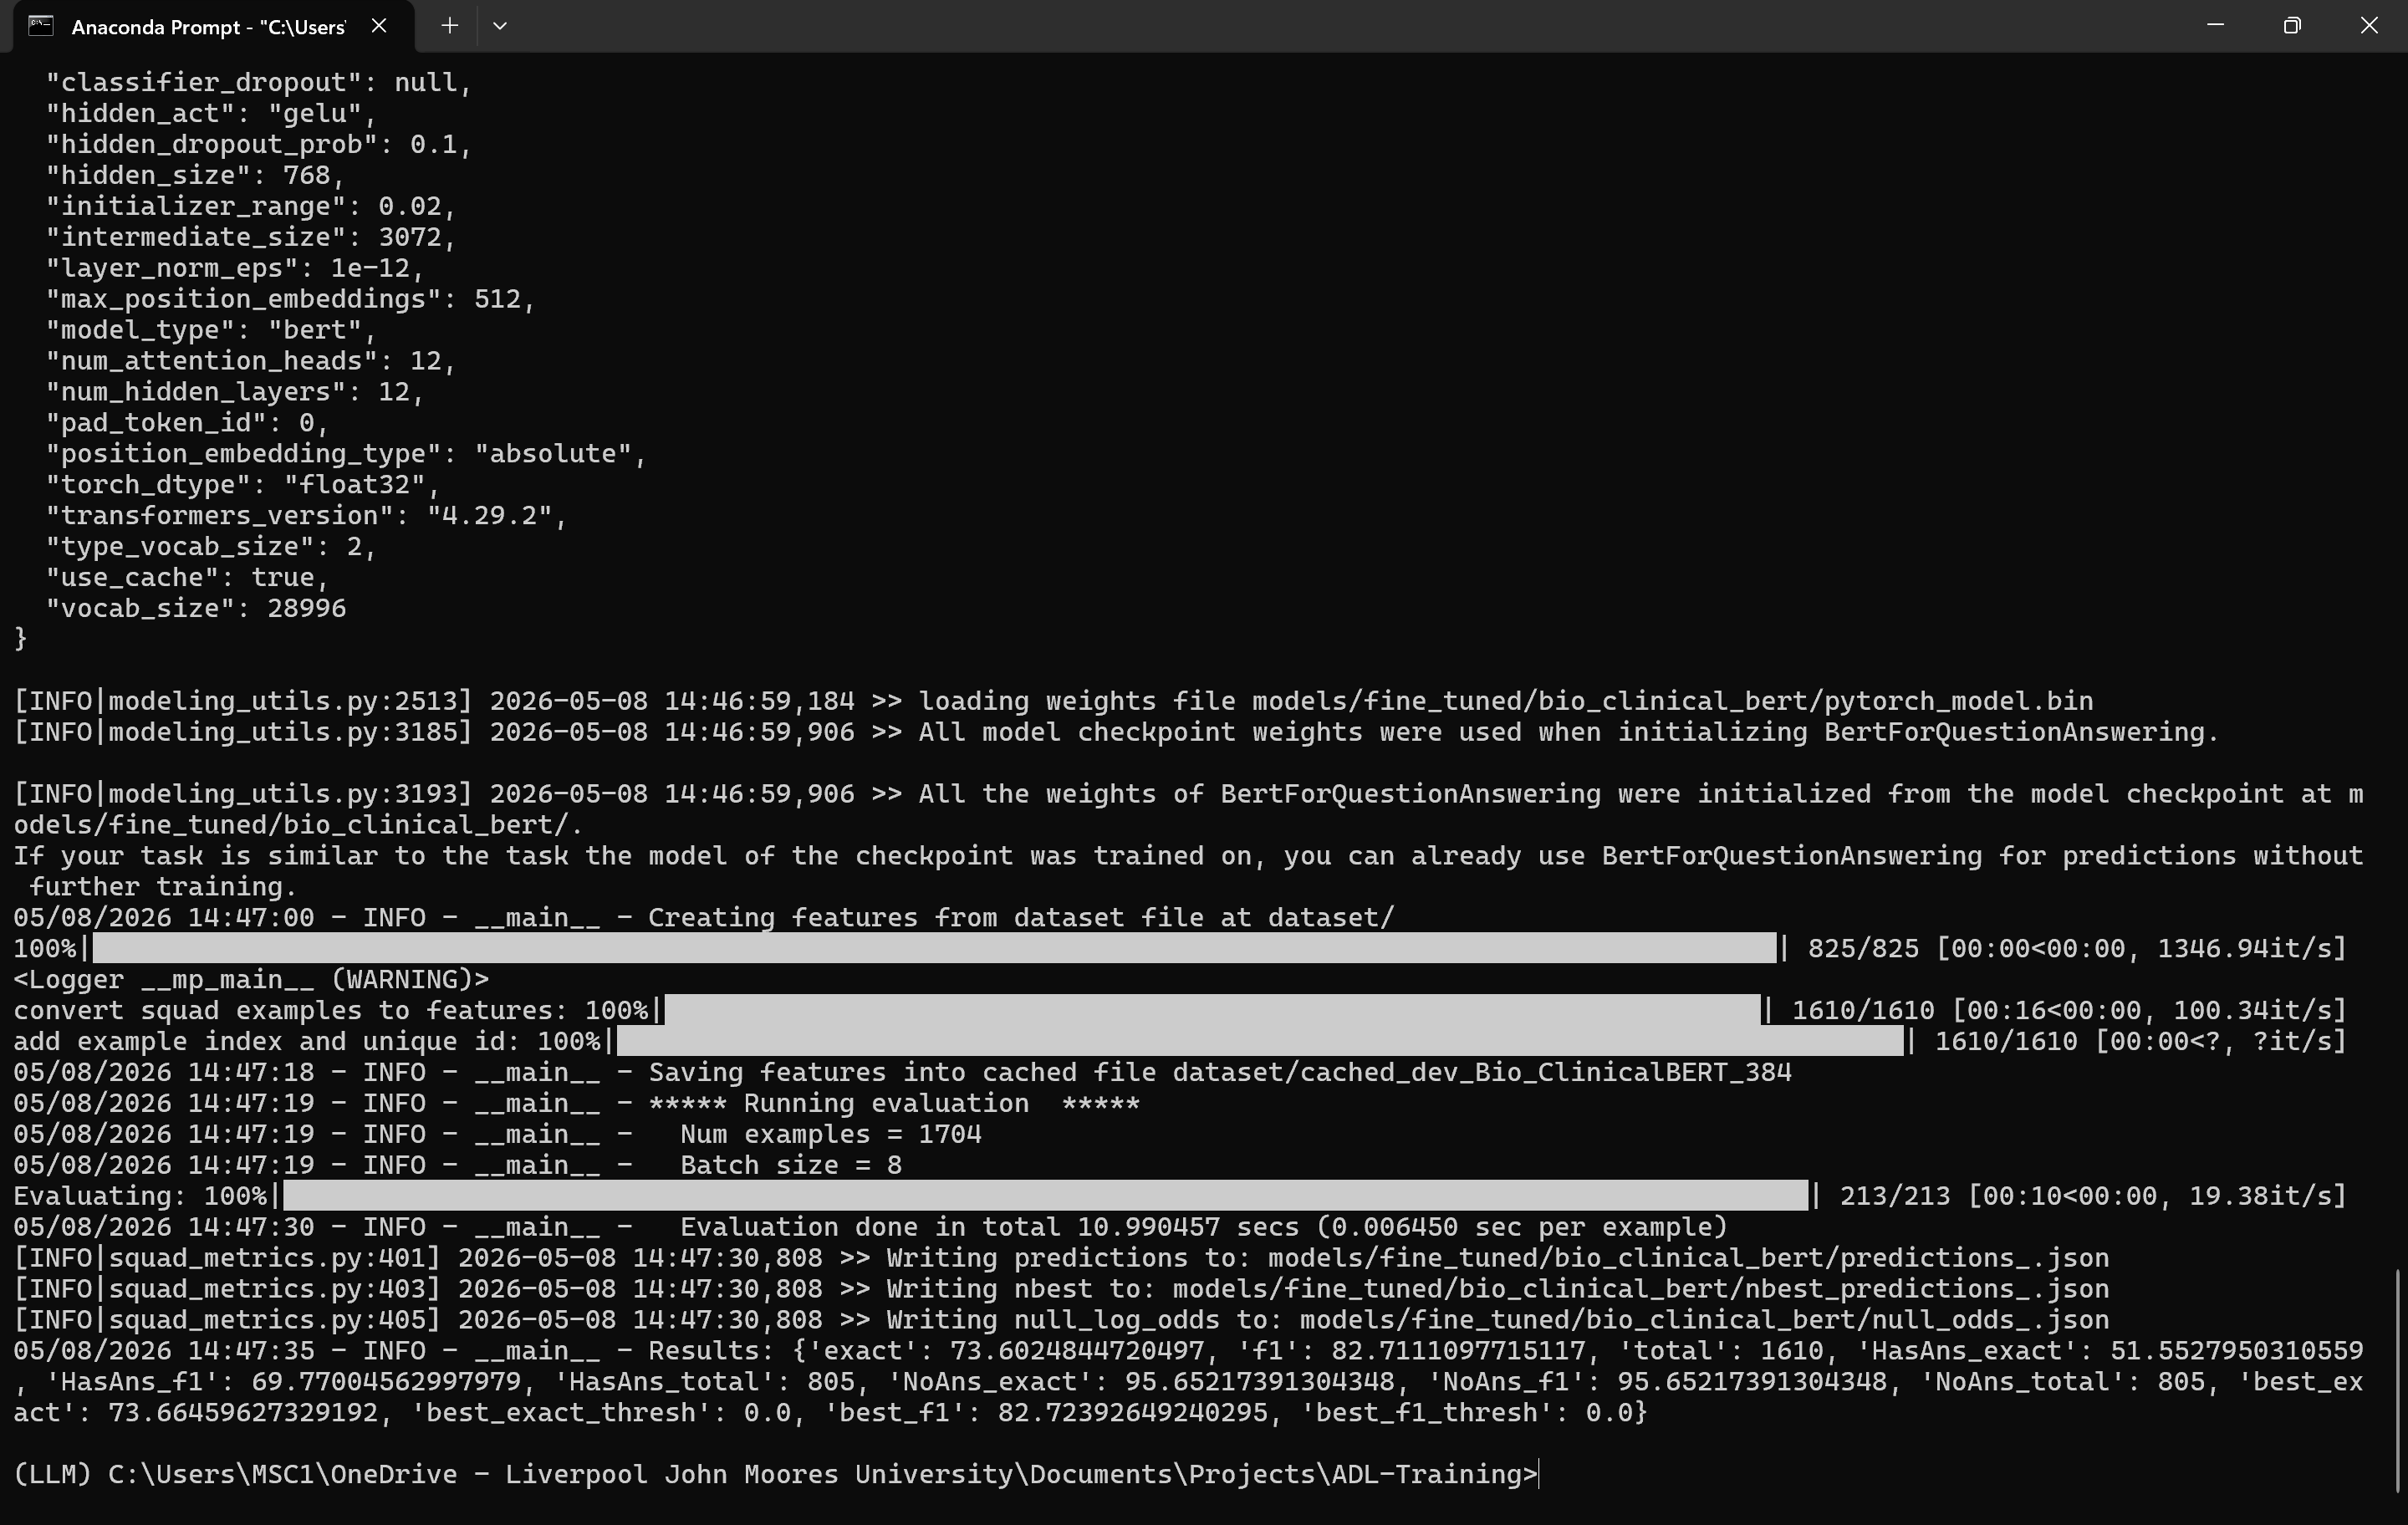

# 5. Evaluation

## 5.1. SQuAD & BERTScore Metrics

In [ ]:

# 1. Define paths
DATA_DIR = "dataset/"
EVAL_FILE = "pressure_ulcer_squad_val.json"
MODEL_DIR = "models/fine_tuned/bio_clinical_bert/"

# run_squad.py typically outputs these specific filenames during evaluation
PREDICTIONS_FILE = MODEL_DIR + "predictions_.json"
NULL_ODDS_FILE = MODEL_DIR + "null_odds_.json"

# 2. Load the Evaluation Dataset
processor = SquadV2Processor()
print("Loading examples...")
examples = processor.get_dev_examples(DATA_DIR, filename=EVAL_FILE)

# 3. Load the predictions and null odds generated by run_squad.py
print("Loading predictions...")
with open(PREDICTIONS_FILE, 'rb') as f:
    preds = json.load(f)

with open(NULL_ODDS_FILE, 'rb') as f:
    null_odds = json.load(f)

# 4. Compute Standard SQuAD 2.0 Metrics (EM & F1)
print("\nComputing SQuAD 2.0 Metrics (EM & F1)...")
squad_results = squad_evaluate(
    examples,
    preds,
    no_answer_probs=null_odds,
    no_answer_probability_threshold=1.0 # Default threshold
)

print("\n--- SQuAD Metrics ---")
print(f"Exact Match (EM): {squad_results['exact']:.2f}")
print(f"F1 Score:       {squad_results['f1']:.2f}")
print(f"Best F1 Score:  {squad_results['best_f1']:.2f} (at threshold {squad_results['best_f1_thresh']:.2f})")

# 5. Prepare Data for BERTScore
print("\nPreparing data for BERTScore (Answerable Questions Only)...")
references = []
predictions = []

for example in examples:
    qas_id = example.qas_id
    if qas_id in preds:
        # Retrieve all possible true answers for the example
        gold_answers = [answer["text"] for answer in example.answers if answer["text"]]
        
        # ONLY include positive examples (questions that actually have answers in the text)
        if gold_answers:
            references.append(gold_answers)
            
            pred_text = preds[qas_id]
            # If the model incorrectly predicted no-answer (empty string) for an answerable question,
            # pass a single space so BERTScore gives it a properly calculated low score 
            # instead of throwing an error and breaking.
            if not pred_text.strip():
                pred_text = " "
                
            predictions.append(pred_text)

# 6. Compute BERTScore (Native API Bypass)
print("Computing BERTScore natively (this may take a moment)...")

# The native API returns PyTorch tensors for Precision (P), Recall (R), and F1
P, R, F1 = score(
    predictions, 
    references, 
    model_type="emilyalsentzer/Bio_ClinicalBERT",
    num_layers=12,  # Explicitly declare the layer count to bypass the KeyError
    verbose=True
)

# 7. Aggregate and Print BERTScore Results
print("\n--- BERTScore Metrics ---")
# .mean().item() extracts the float value from the PyTorch tensor
print(f"Precision: {P.mean().item():.4f}")
print(f"Recall:    {R.mean().item():.4f}")
print(f"F1:        {F1.mean().item():.4f}")

print(f"\nEvaluation completed at timestamp: {int(time.time())}")

Evaluation started at timestamp: 1778095305
Loading examples...


100%|██████████| 825/825 [00:00<00:00, 1342.53it/s]


Loading predictions...

Computing SQuAD 2.0 Metrics (EM & F1)...

--- SQuAD Metrics ---
Exact Match (EM): 73.60
F1 Score:       82.71
Best F1 Score:  82.86 (at threshold -1.20)

Preparing data for BERTScore (Answerable Questions Only)...
Computing BERTScore natively (this may take a moment)...


Some weights of the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


calculating scores...
computing bert embedding.


100%|██████████| 18/18 [00:01<00:00, 16.79it/s]


computing greedy matching.


100%|██████████| 13/13 [00:00<00:00, 72.25it/s]


done in 1.27 seconds, 635.21 sentences/sec

--- BERTScore Metrics ---
Precision: 0.8485
Recall:    0.8411
F1:        0.8438

Evaluation completed at timestamp: 1778095309


## 5.2. Metrics Discussion

The model's performance is evaluated using standard SQuAD metrics - Exact Match (EM) and F1 score. Exact Match measures whether a predicted answer perfectly mirrors any of the ground truth answers, while the F1 score assesses the quality of the answer by measuring token-level similarity. The recorded EM of 73.60% and F1 of 82.71% indicate strong overall accuracy. Because the SQuAD 2.0 dataset includes unanswerable questions, selecting an optimal null threshold is vital for maximizing performance; the "Best F1" of 82.86% demonstrates the benefit of this optimization.

Furthermore, BERTScore provides a semantic evaluation, yielding an F1 of 84.38% for answerable questions. Unlike the token-based SQuAD F1, BERTScore utilizes contextual embeddings to measure similarity. The fact that the BERTScore exceeds the SQuAD F1 suggests that the model’s predictions maintain high semantic alignment with the actual answers, even in cases where exact phrasing or token overlap is missing. Together, these metrics confirm a robust balance between literal precision and semantic relevance.

## 5.3. False Negatives Analysis

In [8]:
# Identify and print False Negatives (Model predicted "no answer" but an answer exists)
print("--- False Negatives Analysis ---")
false_negatives = []

for example in examples:
    qas_id = example.qas_id
    if qas_id in preds:
        # Extract the true answers
        gold_answers = [answer["text"] for answer in example.answers if answer["text"]]
        
        # Clean the prediction to check if it's genuinely empty
        pred_text = preds[qas_id].strip()

        # Condition for False Negative: True answers exist, but prediction is empty
        if gold_answers and not pred_text:
            false_negatives.append({
                "question": example.question_text,
                "context": example.context_text,
                "gold_answers": gold_answers,
                "prediction": preds[qas_id]
            })

print(f"Total False Negatives found: {len(false_negatives)}")
print("Displaying up to 10 examples:\n")

# Print out the details of the first 10 false negatives for manual inspection
for i, fn in enumerate(false_negatives[:10]):
    print(f"Example {i+1}:")
    print(f"Context: {fn['context']}")
    print(f"Question: {fn['question']}")
    print(f"True Answers: {fn['gold_answers']}")
    print(f"Model Predicted: '{fn['prediction']}'")
    print("-" * 60)

--- False Negatives Analysis ---
Total False Negatives found: 70
Displaying up to 10 examples:

Example 1:
Context: The entire network has a tau2 less than 0.001 suggesting no inconsistency or heterogeneity. We present a systematic review and network meta-analysis of the evidence from 65 RCTs (with 14,332 participants) of the relative effects of different types of support surface in terms of pressure ulcer prevention and patient comfort. The specific support surfaces were successfully classified into 14 groups using an established classification system . The included studies form two sparse networks; the studies were heterogeneous in terms of settings, participants’ baseline skin status, and follow-up durations; and over half of the studies had serious or very serious study limitations. All these issues reflect the uncertainty of evidence and the limited data included in each network. There is moderate certainty evidence that powered active air surfaces and powered hybrid air surfaces 

## 5.4. Discussion of Model False Negatives

### 1. "Number & Quantitative" Struggle
* Examples 1, 4, 5, and 6 all require extracting specific numbers (`14,332`, `4`, `2017`, `28.2%`). 
* The model struggles to logically connect a quantitative concept (like "how many total participants") to a raw numeric string in the text.

### 2. Noisy Formatting & Flattened Tables
When structured data (like tables or math equations) is flattened into plain text, the tokenizer gets confused.
* In Example 10, a table has been stripped of its formatting, resulting in mashed strings like `scale5.614.979.55`.
* Example 9 contains LaTeX-style math formatting (`$p_i$`). Special characters often get split into weird sub-tokens, breaking the model's ability to map the question's "p_i" to the context's "$p_i$".

# 5. Deployment

## 5.1. System Architecture Overview

The following diagram illustrates the query-processing pipeline, utilizing Retrieval-Augmented Generation (RAG) for medical informatics.

The workflow begins when a user submits a question via the Client (Web Browser). This request is received by a Flask Frontend, which acts as a bridge, forwarding the query to the central Model Server.

Before generating an answer, the Model Server executes a semantic search against a Qdrant Vector Database to locate relevant, domain-specific literature. Once the database returns this vital context, Clinical BERT synthesizes the information to generate an accurate response. Finally, this data is routed back through the frontend and delivered to the user.

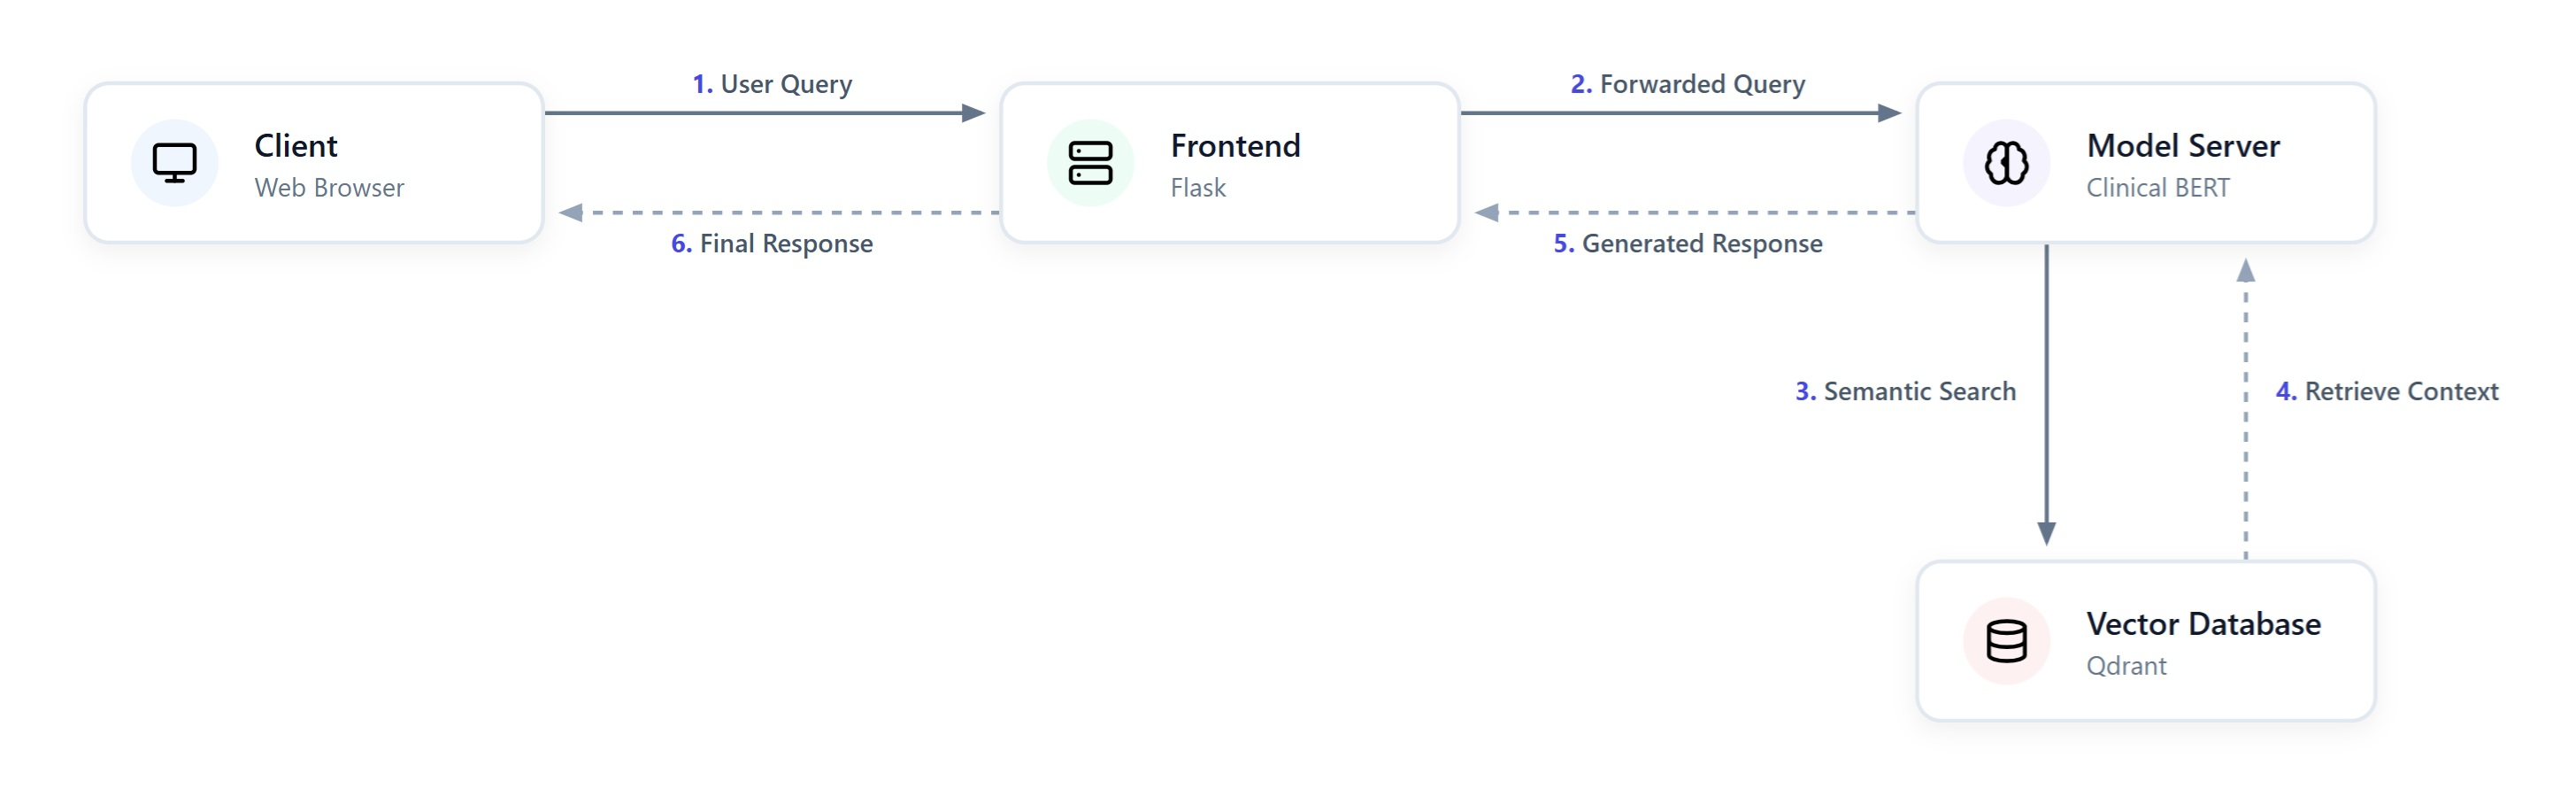

## 5.2. Docker Compose (Frontend & Backend)

<pre>
version: '3.8'

services:
  med-expert-frontend:
    build: 
      context: ./frontend
      dockerfile: Dockerfile
    container_name: flask-frontend
    ports:
      - "8082:8082"
    environment:
      - FLASK_ENV=development
      - MODEL_SERVER_URL=http://med-expert-model-server:8000
      - QDRANT_URL=http://qdrant:6333
    networks:
      - mlops-net
    depends_on:
      - med-expert-model-server
    restart: unless-stopped

  med-expert-model-server:
    build:
      context: ./model-server
      dockerfile: Dockerfile
    container_name: model-server
    ports:
      - "8000:8000"
    volumes:
      - ./models:/app/models
    environment:
      - QDRANT_URL=http://qdrant:6333
      - MODEL_PATH=/app/models/fine_tuned/bio_clinical_bert
      - COLLECTION_NAME=pressure_ulcers
    networks:
      - mlops-net
    restart: unless-stopped

networks:
  mlops-net:
    external: true
    
</pre>

## 5.3. Docker Compose (Core Services)

<pre>

services:
  qdrant:
    image: qdrant/qdrant:latest
    container_name: qdrant-db
    ports:
      - "6333:6333" # REST API
      - "6334:6334" # gRPC API
    volumes:
      - ./qdrant_data:/qdrant/storage
    networks:
      - mlops-net
    restart: unless-stopped
    deploy:
      resources:
        limits:
          memory: 4G # Constrain memory to prevent OOM issues

networks:
  mlops-net:
    external: true

</pre>

## 5.2. Populate Vector Database

In [15]:
# --- Configuration ---
DATA_PATH = './dataset/pressure_ulcer_squad.json'
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
QDRANT_URL = "http://localhost:6333"
COLLECTION_NAME = "pressure_ulcers"
VECTOR_SIZE = 384
BATCH_SIZE = 32

def extract_unique_contexts(file_path):
    """Parses SQuAD JSON and extracts a set of unique context paragraphs."""
    print(f"Loading data from {file_path}...")
    with open(file_path, 'r', encoding='utf-8') as f:
        squad_dict = json.load(f)
    
    unique_contexts = set()
    for article in squad_dict['data']:
        for paragraph in article['paragraphs']:
            unique_contexts.add(paragraph['context'])
            
    print(f"Extracted {len(unique_contexts)} unique contexts.")
    return list(unique_contexts)

def get_mean_pooled_embeddings(texts, tokenizer, model, device):
    """Generates mean-pooled embeddings for a list of texts."""
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Extract the last hidden state and the attention mask
    last_hidden_state = outputs.last_hidden_state
    attention_mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden_state.size()).float()
    
    # Perform mean pooling while ignoring padding tokens
    sum_embeddings = torch.sum(last_hidden_state * attention_mask, 1)
    sum_mask = torch.clamp(attention_mask.sum(1), min=1e-9)
    mean_pooled = sum_embeddings / sum_mask
    
    return mean_pooled.cpu().numpy().tolist()

# ==========================================
# Execution Block 
# ==========================================

# 1. Initialize Model and Tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing embedder on {device}...")

embedder = SentenceTransformer(MODEL_NAME).to(device)

# 2. Connect to Qdrant and Recreate Collection
print("Connecting to Qdrant...")
client = QdrantClient(url=QDRANT_URL)

client.recreate_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=VECTOR_SIZE, distance=Distance.COSINE),
)
print(f"Collection '{COLLECTION_NAME}' is ready.")

# 3. Extract and Process Data
contexts = extract_unique_contexts(DATA_PATH)

# 4. Batch Embed and Upsert
print("Generating embeddings and populating database...")
points = []

total_items = len(contexts)
for i in range(0, total_items, BATCH_SIZE):
    batch_texts = contexts[i:i + BATCH_SIZE]

    # Console feedback
    progress = min(i + BATCH_SIZE, total_items)
    print(f"Processing: {progress}/{total_items} ({(progress/total_items)*100:.1f}%)", end="\r")
    
    # Generate embeddings for the batch
    batch_embeddings = embedder.encode(batch_texts).tolist()
    
    # Create Qdrant PointStructs
    for text, embedding in zip(batch_texts, batch_embeddings):
        point_id = str(uuid.uuid4()) # Generate a unique UUID for each vector
        points.append(
            PointStruct(
                id=point_id, 
                vector=embedding, 
                payload={"context": text} # Store the raw text to retrieve later
            )
        )
        
    # Push batch to Qdrant
    client.upsert(
        collection_name=COLLECTION_NAME,
        points=points
    )
    points.clear() # Clear memory for next batch

print("\nDatabase successfully populated!")

Initializing embedder on cuda...


Loading weights: 100%|████████████████████████████████████████████| 103/103 [00:00<00:00, 7142.25it/s]


Connecting to Qdrant...


C:\Users\MSC1\AppData\Local\Temp\ipykernel_7196\4177082559.py:59: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


Collection 'pressure_ulcers' is ready.
Loading data from ./dataset/pressure_ulcer_squad.json...
Extracted 4076 unique contexts.
Generating embeddings and populating database...
Processing: 4076/4076 (100.0%)
Database successfully populated!


# 6. Inference (RAG)

## 6.1. Answerable Questions

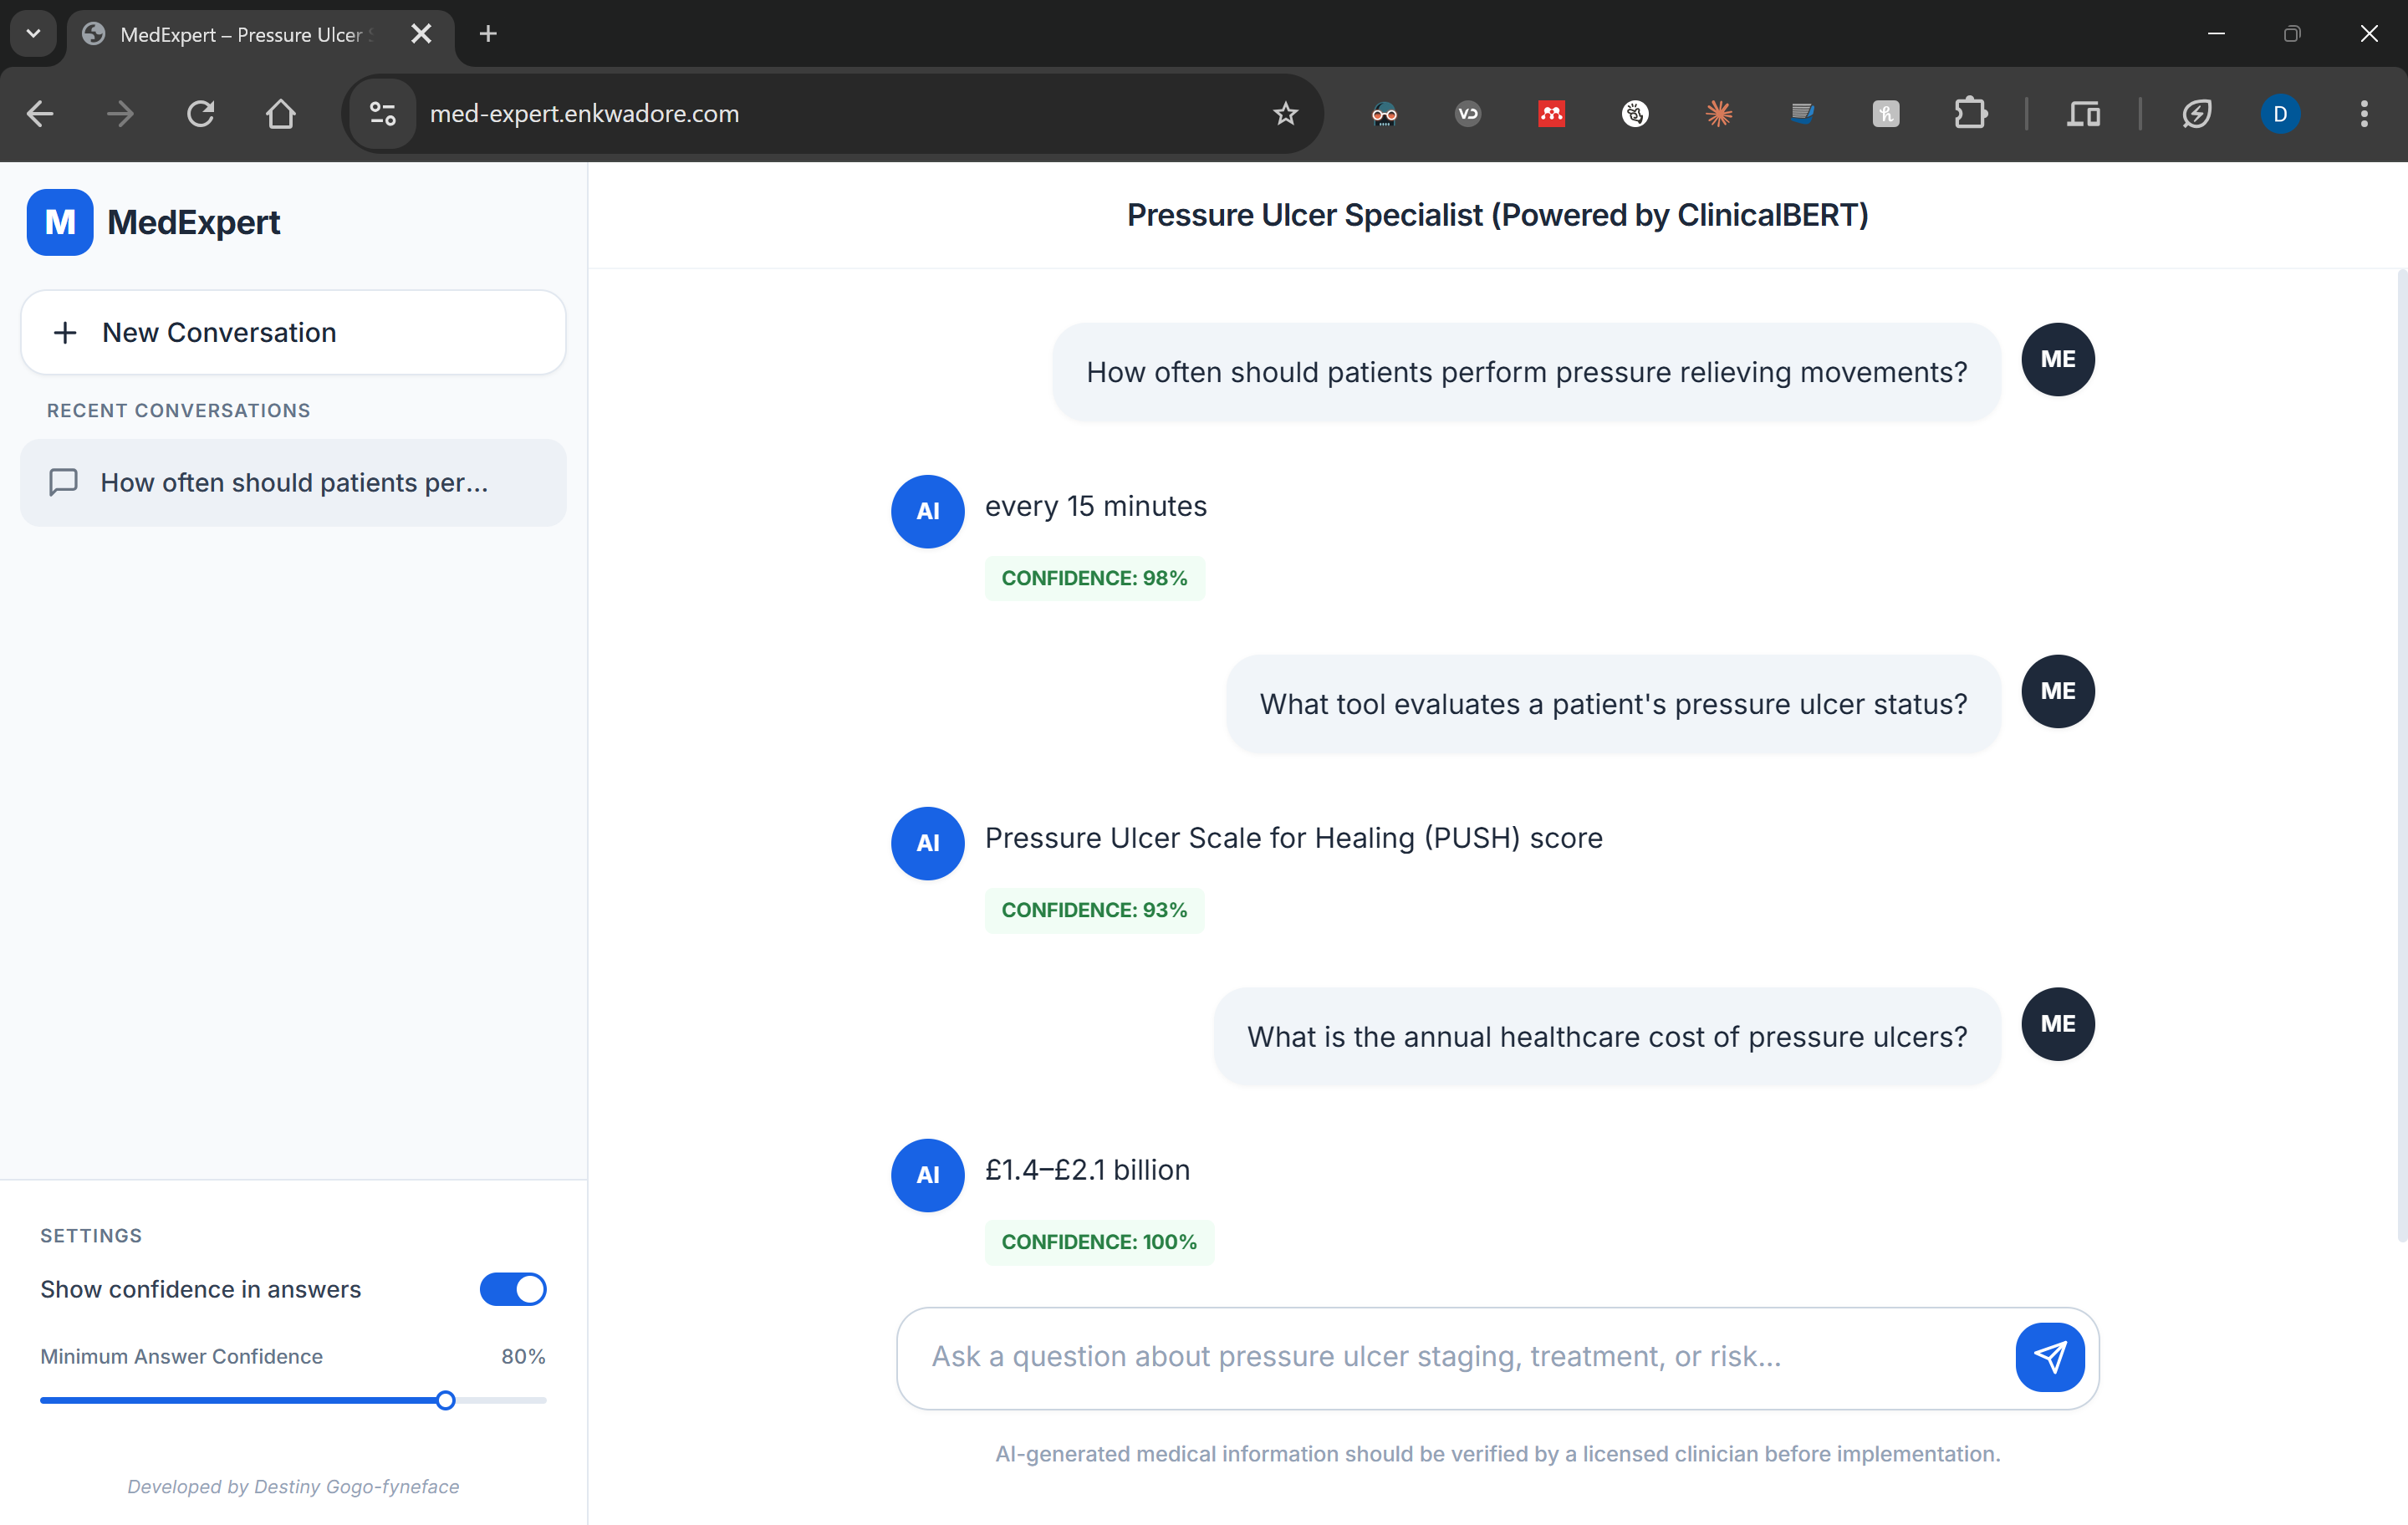

## 6.2. Unanswerable Question

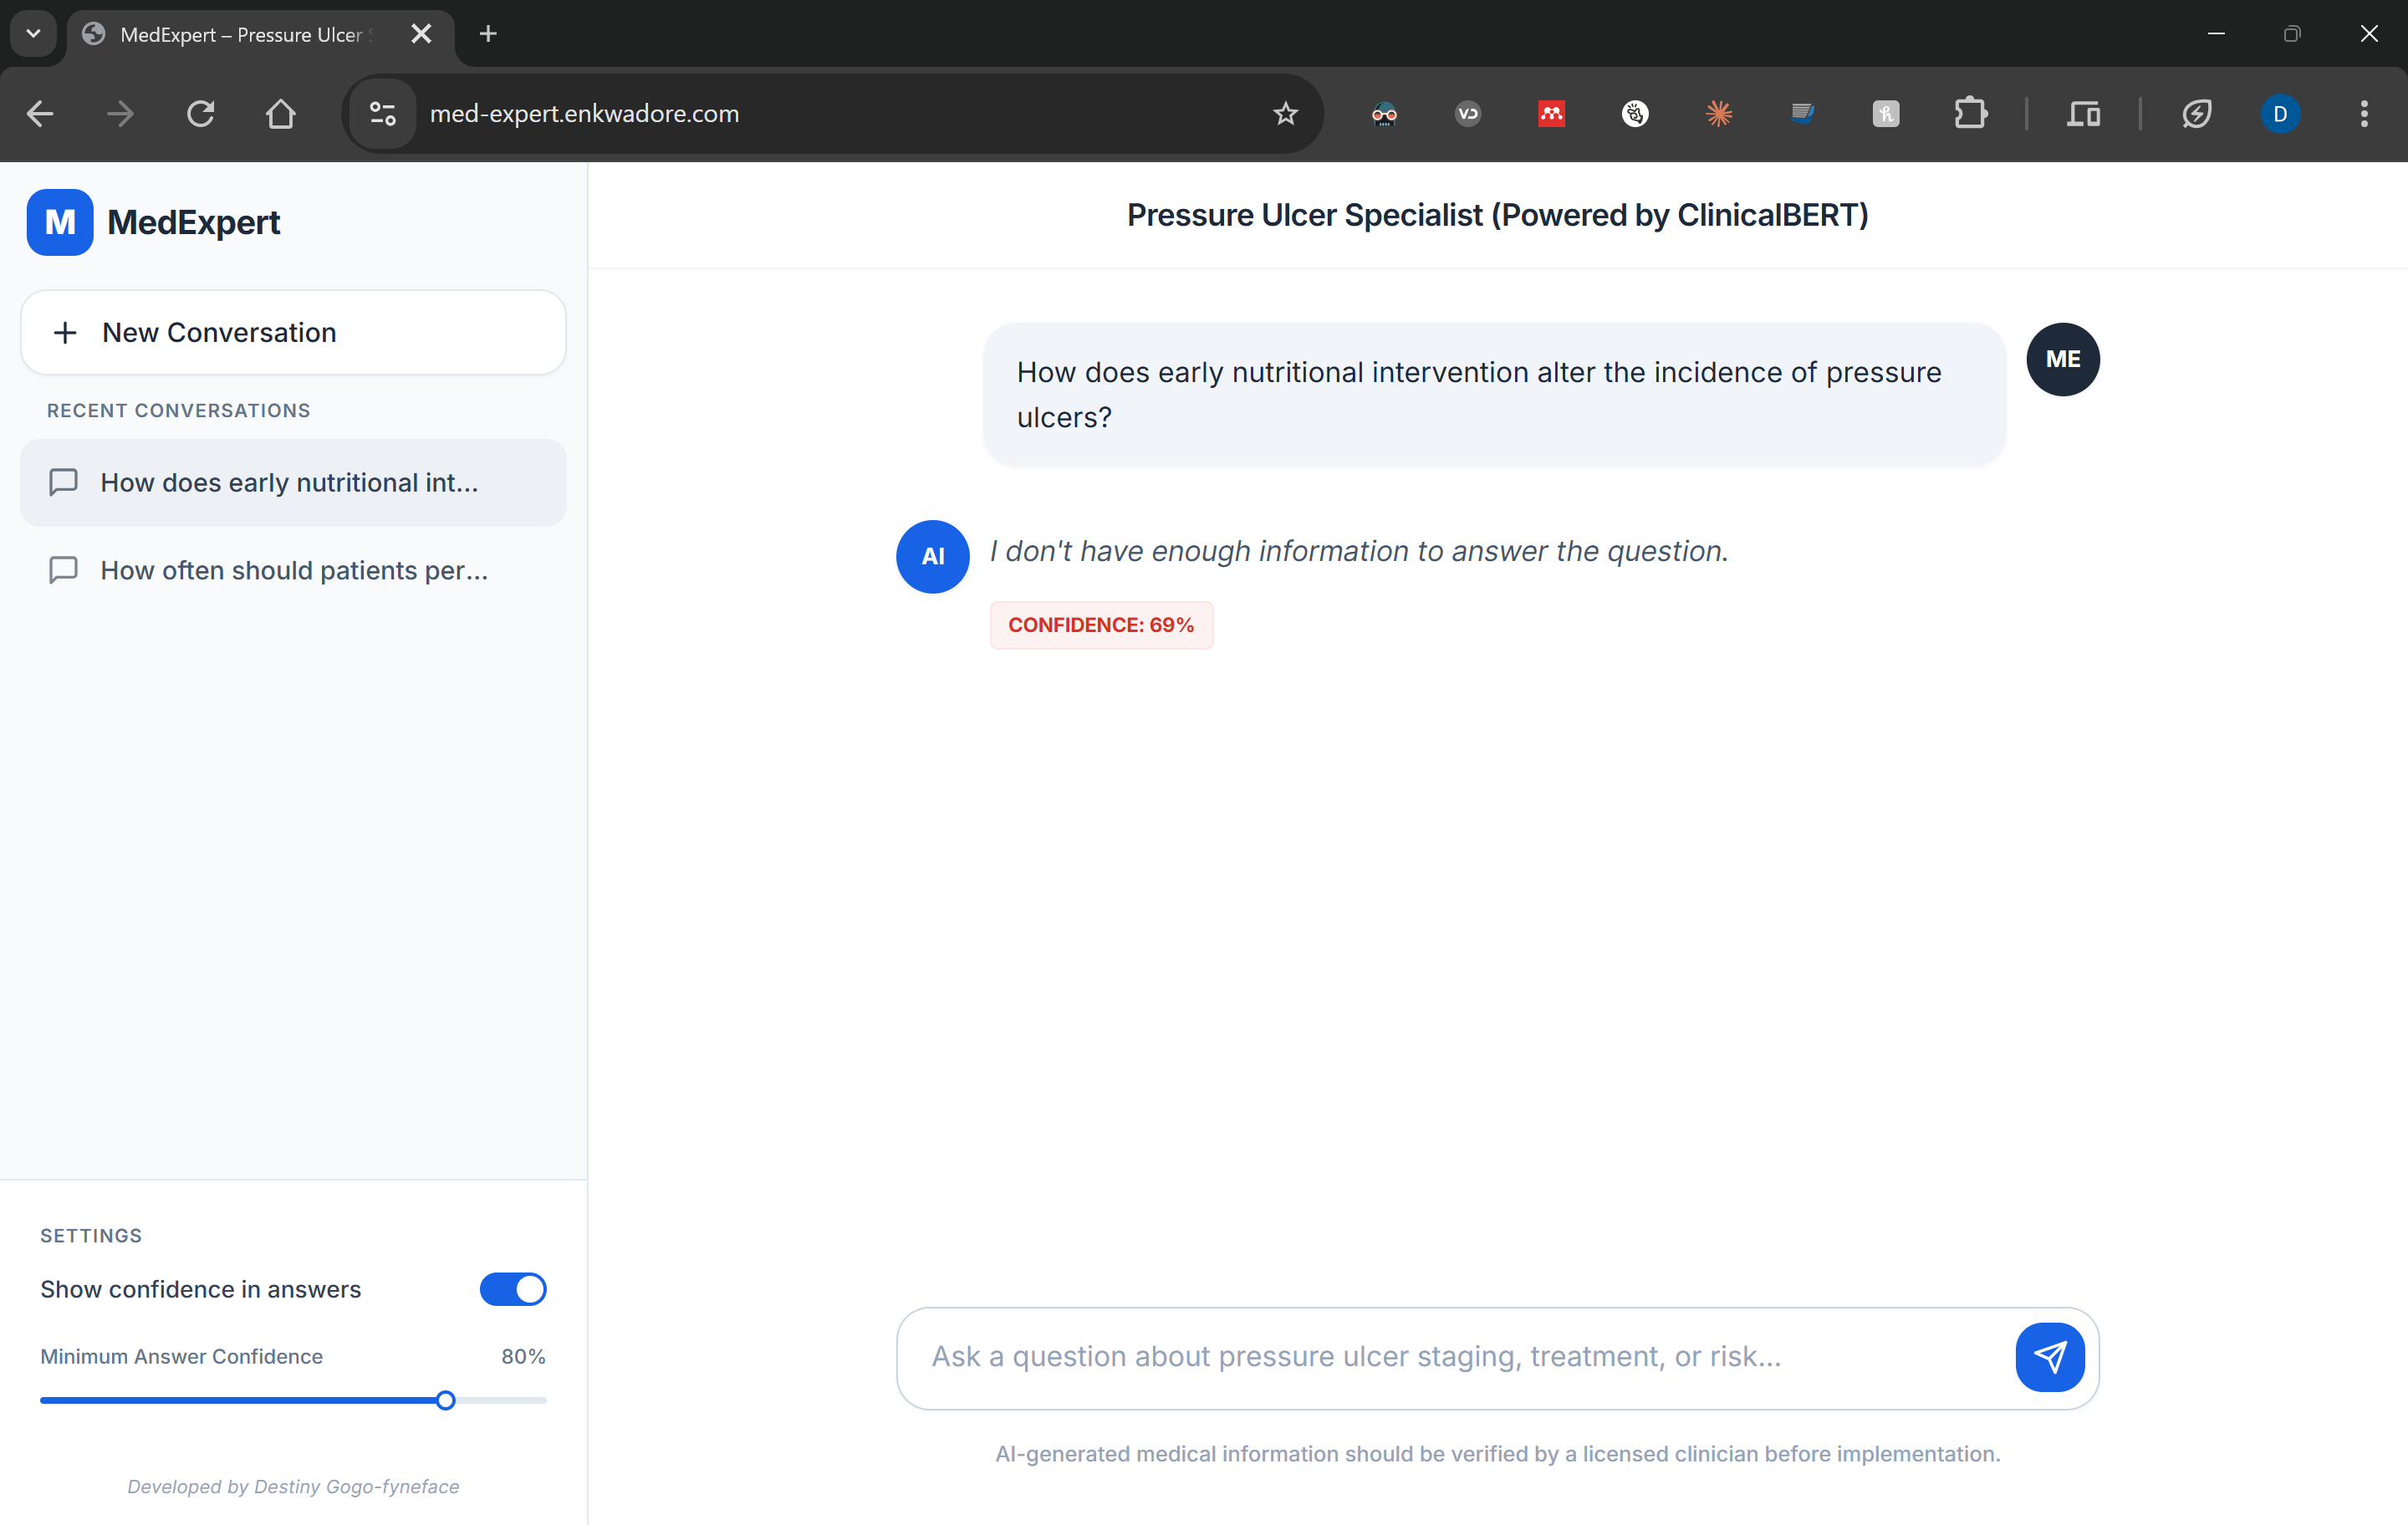

## 6.3. Discussion

The deployed ClinicalBERT model demonstrates strong performance in extractive question answering. By leveraging a balanced SQuAD v2.0 dataset, the model successfully identifies both answerable and unanswerable questions. It safely declines to answer rather than hallucinating potentially harmful medical advice, which is vital for clinical applications.

Building on this foundation, future iterations offer clear pathways for expansion. While the model currently excels at targeted extraction, scaling the training dataset to encompass a wider variety of complex clinical literature would further enhance its capacity to synthesize nuanced inquiries, ultimately broadening its capabilities and clinical utility.